In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
# Load data
data = pd.read_csv("./STOCKNEPSE/NEPSEDATA/adbl.csv")
data = data[['Close']]
data.dropna(inplace=True)

print(data.head())

    Close
0  295.10
1  298.00
2  299.00
3  298.10
4  300.00


In [3]:
# Reverse and clean
data = data.iloc[::-1].reset_index(drop=True)
data['Close'] = data['Close'].str.replace(',', '').astype(float)

# Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

print(scaled_data[:5])

[[0.15698267]
 [0.03771662]
 [0.02446483]
 [0.02140673]
 [0.01732926]]


In [4]:
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60
X, y = create_sequences(scaled_data, TIME_STEPS)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [5]:
# IMPROVED: Use train/validation/test split
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 2417, Val size: 517, Test size: 519


In [6]:
# Build model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))  # IMPROVED: Added return_sequences=False
model.add(Dropout(0.2))
model.add(Dense(32))  # IMPROVED: Added another Dense layer
model.add(Dense(1))

# IMPROVED: Specify learning rate for Adam
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['mae']  # IMPROVED: Added MAE metric
)

model.summary()


D:\VS code for code\spa\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# IMPROVED: Better callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Increased patience
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=1
)

In [8]:
# Save best model
checkpoint = ModelCheckpoint(
    'best_lstm_stock_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


In [9]:
# IMPROVED: Train with validation data (not test data!)
history = model.fit(
    X_train,
    y_train,
    epochs=50,  # Increased epochs (early stopping will stop if needed)
    batch_size=32,
    validation_data=(X_val, y_val),  # Use validation set
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

Epoch 1/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0104 - mae: 0.0697
Epoch 1: val_loss improved from None to 0.00022, saving model to best_lstm_stock_model.h5



Epoch 1: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0046 - mae: 0.0435 - val_loss: 2.1693e-04 - val_mae: 0.0105 - learning_rate: 0.0010
Epoch 2/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0017 - mae: 0.0269
Epoch 2: val_loss did not improve from 0.00022
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0018 - mae: 0.0270 - val_loss: 4.6593e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 3/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0015 - mae: 0.0260
Epoch 3: val_loss improved from 0.00022 to 0.00016, saving model to best_lstm_stock_model.h5



Epoch 3: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0014 - mae: 0.0244 - val_loss: 1.5715e-04 - val_mae: 0.0086 - learning_rate: 0.0010
Epoch 4/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0011 - mae: 0.0222
Epoch 4: val_loss did not improve from 0.00016
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0012 - mae: 0.0228 - val_loss: 1.7576e-04 - val_mae: 0.0092 - learning_rate: 0.0010
Epoch 5/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0012 - mae: 0.0236
Epoch 5: val_loss did not improve from 0.00016
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0012 - mae: 0.0228 - val_loss: 2.7367e-04 - val_mae: 0.0133 - learning_rate: 0.0010
Epoch 6/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 9.1338e-04 - mae: 0.0198
Epoch 6: val_loss did not improve from 0.00016
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0011 - mae: 0.0202 - val_loss: 2.3318e-04 - val_mae: 0.0125 - learning_rate: 0.0010
Epoch 7/50
75/76 ━━


Epoch 10: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 7.5778e-04 - mae: 0.0176 - val_loss: 1.4230e-04 - val_mae: 0.0083 - learning_rate: 5.0000e-04
Epoch 11/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.3168e-04 - mae: 0.0183
Epoch 11: val_loss did not improve from 0.00014
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.0320e-04 - mae: 0.0175 - val_loss: 1.4943e-04 - val_mae: 0.0084 - learning_rate: 5.0000e-04
Epoch 12/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.2569e-04 - mae: 0.0167
Epoch 12: val_loss did not improve from 0.00014
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 6.7325e-04 - mae: 0.0168 - val_loss: 1.7393e-04 - val_mae: 0.0089 - learning_rate: 5.0000e-04
Epoch 13/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.0302e-04 - mae: 0.0174
Epoch 13: val_loss improved from 0.00014 to 0.00013, saving model to best_lstm_stock_model.h5



Epoch 13: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 7.2255e-04 - mae: 0.0167 - val_loss: 1.3358e-04 - val_mae: 0.0081 - learning_rate: 5.0000e-04
Epoch 14/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.8799e-04 - mae: 0.0170
Epoch 14: val_loss did not improve from 0.00013
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 7.2160e-04 - mae: 0.0164 - val_loss: 1.4483e-04 - val_mae: 0.0089 - learning_rate: 5.0000e-04
Epoch 15/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 5.7345e-04 - mae: 0.0163
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: val_loss did not improve from 0.00013
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 6.4354e-04 - mae: 0.0165 - val_loss: 1.8438e-04 - val_mae: 0.0107 - learning_rate: 5.0000e-04
Epoch 16/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.1890e-04 - mae: 0.0166
Epoch 16: val_loss improved from 0.00013 to 0.00012, saving model to best_lstm_stock

...


Epoch 26: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.6417e-04 - mae: 0.0146 - val_loss: 1.1229e-04 - val_mae: 0.0071 - learning_rate: 1.2500e-04
Epoch 27/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 5.7329e-04 - mae: 0.0142
Epoch 27: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.9133e-04 - mae: 0.0148 - val_loss: 1.3001e-04 - val_mae: 0.0080 - learning_rate: 1.2500e-04
Epoch 28/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.2414e-04 - mae: 0.0136
Epoch 28: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.6956e-04 - mae: 0.0144 - val_loss: 1.5130e-04 - val_mae: 0.0096 - learning_rate: 1.2500e-04
Epoch 29/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 5.5998e-04 - mae: 0.0147
Epoch 29: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.6331e-04 - mae: 0.0149 - val_loss: 1.1424e-04 - val_mae: 0.0071 


Epoch 32: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.3354e-04 - mae: 0.0147 - val_loss: 1.0978e-04 - val_mae: 0.0070 - learning_rate: 1.2500e-04
Epoch 33/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 5.5762e-04 - mae: 0.0147
Epoch 33: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 33: val_loss improved from 0.00011 to 0.00011, saving model to best_lstm_stock_model.h5



Epoch 33: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.3412e-04 - mae: 0.0142 - val_loss: 1.0728e-04 - val_mae: 0.0069 - learning_rate: 1.2500e-04
Epoch 34/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 5.4209e-04 - mae: 0.0141
Epoch 34: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.3808e-04 - mae: 0.0140 - val_loss: 1.2308e-04 - val_mae: 0.0076 - learning_rate: 6.2500e-05
Epoch 35/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.4913e-04 - mae: 0.0147
Epoch 35: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.5779e-04 - mae: 0.0144 - val_loss: 1.3139e-04 - val_mae: 0.0085 - learning_rate: 6.2500e-05
Epoch 36/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.3946e-04 - mae: 0.0133
Epoch 36: val_loss did not improve from 0.00011
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.0509e-04 - mae: 0.0140 - val_loss: 1.1491e-04 - val_mae: 0.0074 


Epoch 37: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 5.1478e-04 - mae: 0.0139 - val_loss: 1.0419e-04 - val_mae: 0.0066 - learning_rate: 6.2500e-05
Epoch 38/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.7080e-04 - mae: 0.0136
Epoch 38: val_loss did not improve from 0.00010
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.0708e-04 - mae: 0.0138 - val_loss: 1.2307e-04 - val_mae: 0.0082 - learning_rate: 6.2500e-05
Epoch 39/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.9347e-04 - mae: 0.0137
Epoch 39: val_loss did not improve from 0.00010
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.2003e-04 - mae: 0.0140 - val_loss: 1.0555e-04 - val_mae: 0.0069 - learning_rate: 6.2500e-05
Epoch 40/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.3894e-04 - mae: 0.0134
Epoch 40: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 40: val_loss improved from 0.00010 to 0.00010, saving model to best_lstm_stock


Epoch 40: finished saving model to best_lstm_stock_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.4504e-04 - mae: 0.0142 - val_loss: 1.0358e-04 - val_mae: 0.0066 - learning_rate: 6.2500e-05
Epoch 41/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 5.0907e-04 - mae: 0.0139
Epoch 41: val_loss did not improve from 0.00010
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 5.2252e-04 - mae: 0.0140 - val_loss: 1.1902e-04 - val_mae: 0.0078 - learning_rate: 3.1250e-05
Epoch 42/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5.1202e-04 - mae: 0.0145
Epoch 42: val_loss did not improve from 0.00010
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 4.9136e-04 - mae: 0.0141 - val_loss: 1.2032e-04 - val_mae: 0.0076 - learning_rate: 3.1250e-05
Epoch 43/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5.8730e-04 - mae: 0.0147
Epoch 43: val_loss did not improve from 0.00010
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 5.3627e-04 - mae: 0.0144 - val_loss: 1.2511e-04 - val_mae: 0.0081 

In [10]:
# Load best model
from tensorflow.keras.models import load_model
model = load_model("best_lstm_stock_model.h5")

In [11]:
# IMPROVED: Evaluate on all sets
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# Inverse transform
train_pred = scaler.inverse_transform(train_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

val_pred = scaler.inverse_transform(val_pred)
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    explained_variance_score
)
from scipy import stats



Step 12: Calculating metrics...

Training Set - Comprehensive Metrics

 Error Metrics:
  RMSE (Root Mean Squared Error):        18.3572
  MAE (Mean Absolute Error):              9.7743
  MedAE (Median Absolute Error):          5.1452
  Max Error:                              309.8651

📈 Percentage Metrics:
  MAPE (Mean Absolute Percentage Error):  2.43%
  sMAPE (Symmetric MAPE):                 2.45%

 Accuracy Metrics:
  R² Score:                               0.9886
  Explained Variance Score:               0.9891
  Direction Accuracy:                     50.33%

 Bias Metric:
  Mean Bias Error (MBE):                  -3.5591

 Interpretation:
   Excellent R² - model explains 98.9% of variance
   Excellent MAPE - very accurate predictions
   Low direction accuracy - struggles with trend direction
   Negative bias - tends to UNDERPREDICT by 3.5591

Validation Set - Comprehensive Metrics

 Error Metrics:
  RMSE (Root Mean Squared Error):        9.9842
  MAE (Mean Absolute Error):     

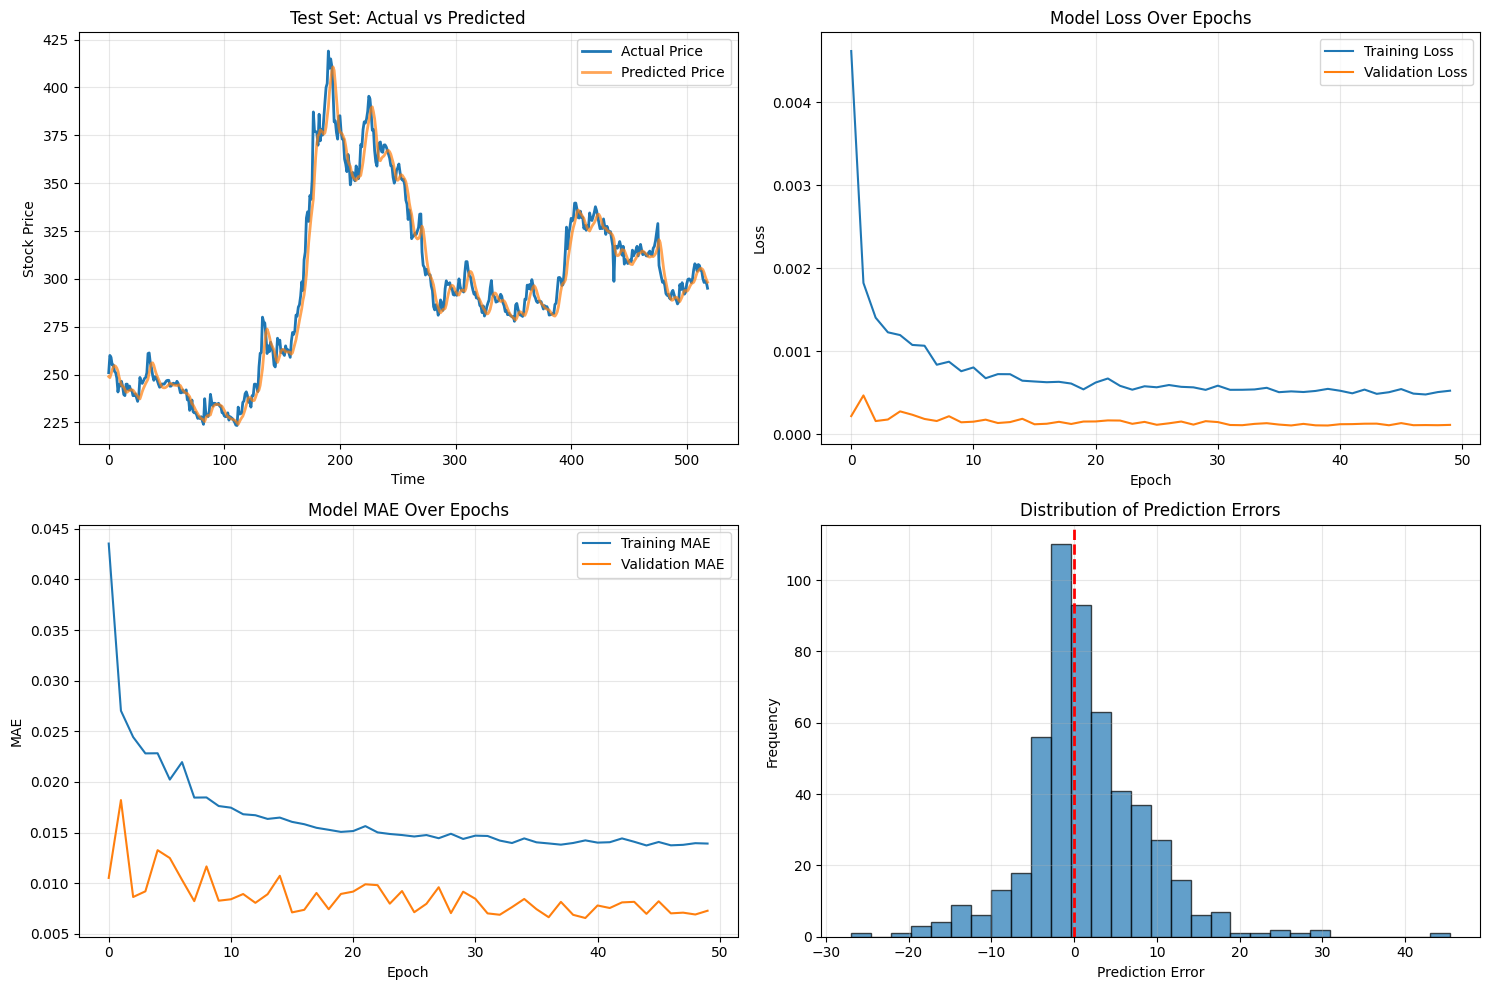


Step 14: Creating additional visualizations...


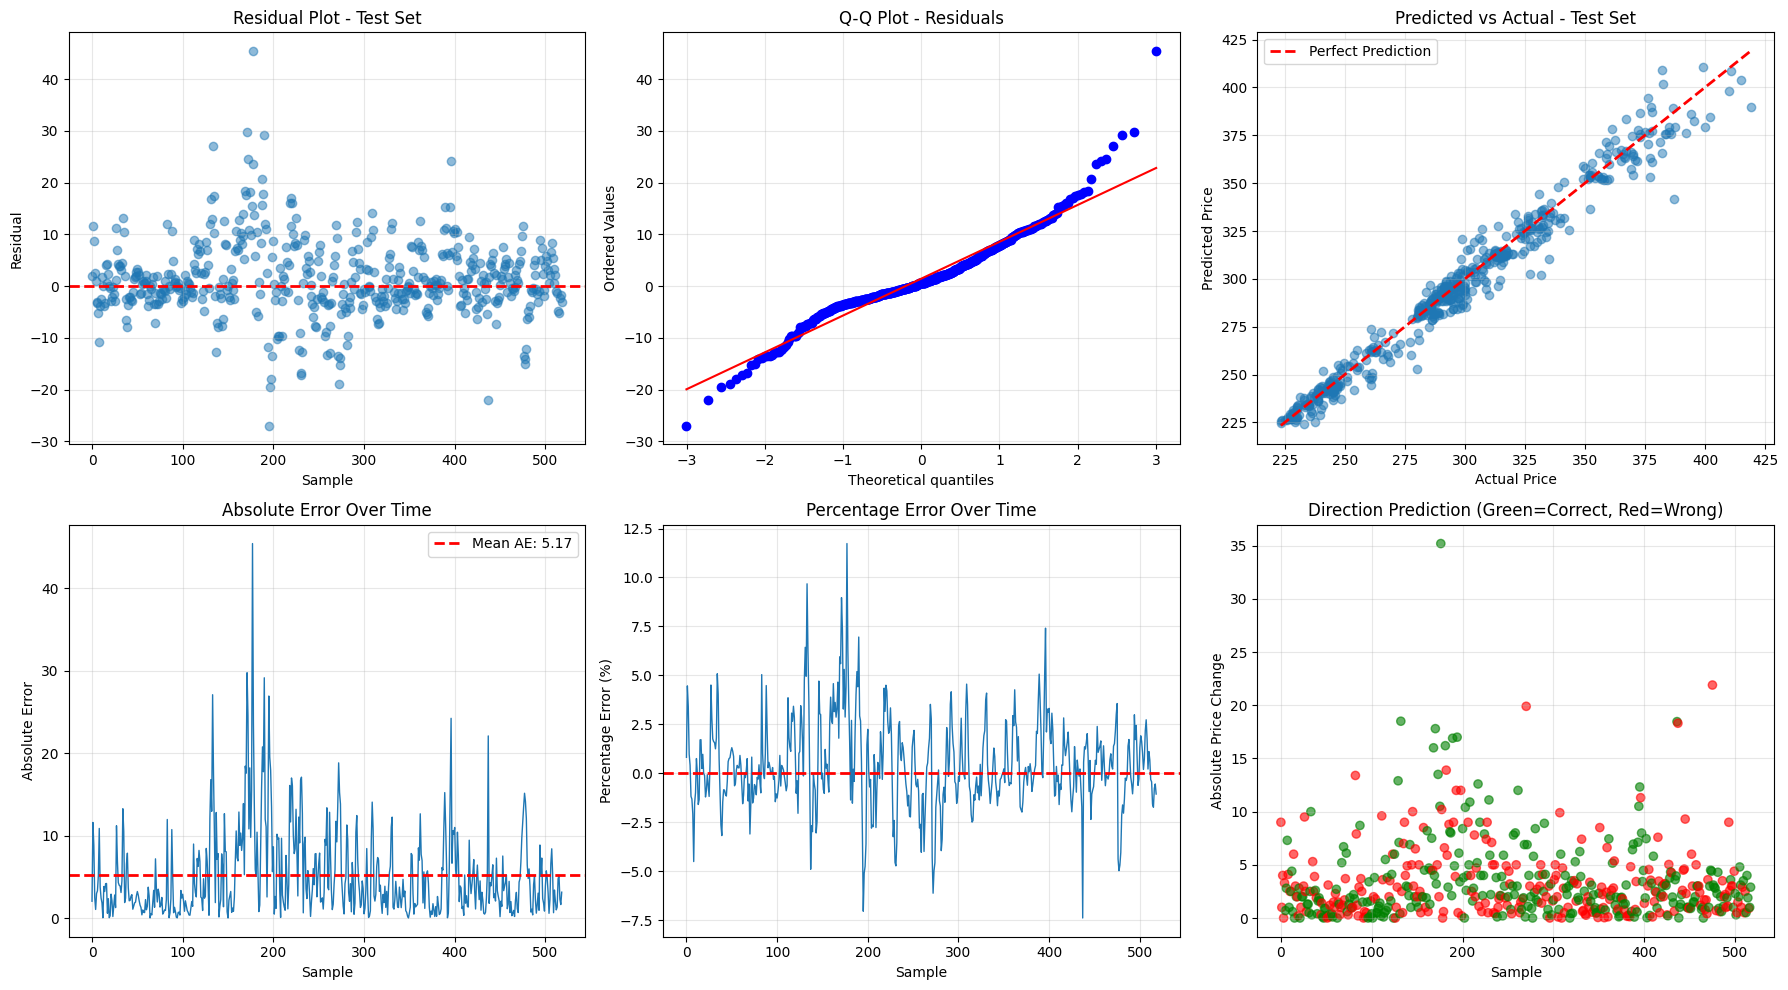


📋 METRICS COMPARISON TABLE
Metric                              Training           Validation         Test              
RMSE                                18.3572            9.9842             7.4498            
MAE                                 9.7743             6.4467             5.1722            
MAPE (%)                            2.43               1.81               1.69              
R² Score                            0.9886             0.9886             0.9723            
Direction Accuracy (%)              50.33              53.49              53.47             


In [13]:
print("\nStep 12: Calculating metrics...")

def calculate_comprehensive_metrics(actual, predicted, set_name):
    """Calculate comprehensive error metrics"""
    
    # Basic metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    # Additional metrics
    medae = median_absolute_error(actual, predicted)
    evs = explained_variance_score(actual, predicted)
    
    # sMAPE
    smape = np.mean(2.0 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted))) * 100
    
    # Max Error
    max_error = np.max(np.abs(actual - predicted))
    
    # Direction Accuracy
    if len(actual) > 1:
        actual_direction = np.diff(actual.flatten()) > 0
        predicted_direction = np.diff(predicted.flatten()) > 0
        direction_accuracy = np.mean(actual_direction == predicted_direction) * 100
    else:
        direction_accuracy = None
    
    # Mean Bias Error
    mbe = np.mean(predicted - actual)
    
    # Print results
    print(f"\n{'='*70}")
    print(f"{set_name} Set - Comprehensive Metrics")
    print(f"{'='*70}")
    
    print(f"\n Error Metrics:")
    print(f"  RMSE (Root Mean Squared Error):        {rmse:.4f}")
    print(f"  MAE (Mean Absolute Error):              {mae:.4f}")
    print(f"  MedAE (Median Absolute Error):          {medae:.4f}")
    print(f"  Max Error:                              {max_error:.4f}")
    
    print(f"\n📈 Percentage Metrics:")
    print(f"  MAPE (Mean Absolute Percentage Error):  {mape:.2f}%")
    print(f"  sMAPE (Symmetric MAPE):                 {smape:.2f}%")
    
    print(f"\n Accuracy Metrics:")
    print(f"  R² Score:                               {r2:.4f}")
    print(f"  Explained Variance Score:               {evs:.4f}")
    if direction_accuracy is not None:
        print(f"  Direction Accuracy:                     {direction_accuracy:.2f}%")
    
    print(f"\n Bias Metric:")
    print(f"  Mean Bias Error (MBE):                  {mbe:.4f}")
    
    # Interpretation
    print(f"\n Interpretation:")
    if r2 > 0.9:
        print(f"   Excellent R² - model explains {r2*100:.1f}% of variance")
    elif r2 > 0.7:
        print(f"   Good R² - model explains {r2*100:.1f}% of variance")
    elif r2 > 0.5:
        print(f"  Moderate R² - model explains {r2*100:.1f}% of variance")
    else:
        print(f"  Low R² - model needs improvement")
    
    if mape < 5:
        print(f"   Excellent MAPE - very accurate predictions")
    elif mape < 10:
        print(f"   Good MAPE - reliable predictions")
    elif mape < 20:
        print(f"   Moderate MAPE - acceptable for stock prediction")
    else:
        print(f"   High MAPE - predictions may be unreliable")
    
    if direction_accuracy is not None:
        if direction_accuracy > 60:
            print(f" Good direction accuracy - {direction_accuracy:.1f}% correct trend")
        else:
            print(f"   Low direction accuracy - struggles with trend direction")
    
    if abs(mbe) < mae * 0.1:
        print(f"  Low bias - predictions are well-centered")
    else:
        if mbe > 0:
            print(f"   Positive bias - tends to OVERPREDICT by {abs(mbe):.4f}")
        else:
            print(f"   Negative bias - tends to UNDERPREDICT by {abs(mbe):.4f}")
    
    return {
        'rmse': rmse, 'mae': mae, 'medae': medae, 'max_error': max_error,
        'mape': mape, 'smape': smape, 'r2': r2, 'evs': evs,
        'direction_accuracy': direction_accuracy, 'mbe': mbe
    }

train_metrics = calculate_comprehensive_metrics(y_train_actual, train_pred, "Training")
val_metrics = calculate_comprehensive_metrics(y_val_actual, val_pred, "Validation")
test_metrics = calculate_comprehensive_metrics(y_test_actual, test_pred, "Test")

# Step 13: First set of visualizations
print("\nStep 13: Creating visualizations...")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Test predictions
axes[0, 0].plot(y_test_actual, label='Actual Price', linewidth=2)
axes[0, 0].plot(test_pred, label='Predicted Price', linewidth=2, alpha=0.7)
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Stock Price")
axes[0, 0].set_title("Test Set: Actual vs Predicted")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training history - Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss')
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_title("Model Loss Over Epochs")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training history - MAE
axes[1, 0].plot(history.history['mae'], label='Training MAE')
axes[1, 0].plot(history.history['val_mae'], label='Validation MAE')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].set_title("Model MAE Over Epochs")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Prediction errors
errors = y_test_actual - test_pred
axes[1, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel("Prediction Error")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Distribution of Prediction Errors")
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 14: Additional comprehensive visualizations
print("\nStep 14: Creating additional visualizations...")
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Residuals over time
residuals_test = y_test_actual.flatten() - test_pred.flatten()
axes2[0, 0].scatter(range(len(residuals_test)), residuals_test, alpha=0.5)
axes2[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes2[0, 0].set_xlabel("Sample")
axes2[0, 0].set_ylabel("Residual")
axes2[0, 0].set_title("Residual Plot - Test Set")
axes2[0, 0].grid(True, alpha=0.3)

# Plot 2: Q-Q plot
stats.probplot(residuals_test, dist="norm", plot=axes2[0, 1])
axes2[0, 1].set_title("Q-Q Plot - Residuals")
axes2[0, 1].grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual scatter
axes2[0, 2].scatter(y_test_actual, test_pred, alpha=0.5)
axes2[0, 2].plot([y_test_actual.min(), y_test_actual.max()], 
                  [y_test_actual.min(), y_test_actual.max()], 
                  'r--', lw=2, label='Perfect Prediction')
axes2[0, 2].set_xlabel("Actual Price")
axes2[0, 2].set_ylabel("Predicted Price")
axes2[0, 2].set_title("Predicted vs Actual - Test Set")
axes2[0, 2].legend()
axes2[0, 2].grid(True, alpha=0.3)

# Plot 4: Absolute error over time
abs_errors = np.abs(residuals_test)
axes2[1, 0].plot(abs_errors, linewidth=1)
axes2[1, 0].axhline(y=np.mean(abs_errors), color='r', linestyle='--', 
                     linewidth=2, label=f'Mean AE: {np.mean(abs_errors):.2f}')
axes2[1, 0].set_xlabel("Sample")
axes2[1, 0].set_ylabel("Absolute Error")
axes2[1, 0].set_title("Absolute Error Over Time")
axes2[1, 0].legend()
axes2[1, 0].grid(True, alpha=0.3)

# Plot 5: Percentage error over time
pct_errors = (residuals_test / y_test_actual.flatten()) * 100
axes2[1, 1].plot(pct_errors, linewidth=1)
axes2[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes2[1, 1].set_xlabel("Sample")
axes2[1, 1].set_ylabel("Percentage Error (%)")
axes2[1, 1].set_title("Percentage Error Over Time")
axes2[1, 1].grid(True, alpha=0.3)

# Plot 6: Direction accuracy visualization - FIXED
if len(y_test_actual) > 1:
    actual_changes = np.diff(y_test_actual.flatten())
    predicted_changes = np.diff(test_pred.flatten())
    correct_direction = (actual_changes > 0) == (predicted_changes > 0)
    
    colors = ['green' if c else 'red' for c in correct_direction]
    # FIX: Use the same length for x and y
    axes2[1, 2].scatter(range(len(correct_direction)), 
                        np.abs(actual_changes),  # REMOVED [:-1] 
                        c=colors, alpha=0.6)
    axes2[1, 2].set_xlabel("Sample")
    axes2[1, 2].set_ylabel("Absolute Price Change")
    axes2[1, 2].set_title(f"Direction Prediction (Green=Correct, Red=Wrong)")
    axes2[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 15: Metrics comparison table
print("\n" + "="*90)
print("📋 METRICS COMPARISON TABLE")
print("="*90)
print(f"{'Metric':<35} {'Training':<18} {'Validation':<18} {'Test':<18}")
print("="*90)
print(f"{'RMSE':<35} {train_metrics['rmse']:<18.4f} {val_metrics['rmse']:<18.4f} {test_metrics['rmse']:<18.4f}")
print(f"{'MAE':<35} {train_metrics['mae']:<18.4f} {val_metrics['mae']:<18.4f} {test_metrics['mae']:<18.4f}")
print(f"{'MAPE (%)':<35} {train_metrics['mape']:<18.2f} {val_metrics['mape']:<18.2f} {test_metrics['mape']:<18.2f}")
print(f"{'R² Score':<35} {train_metrics['r2']:<18.4f} {val_metrics['r2']:<18.4f} {test_metrics['r2']:<18.4f}")
if test_metrics['direction_accuracy'] is not None:
    print(f"{'Direction Accuracy (%)':<35} {train_metrics['direction_accuracy']:<18.2f} {val_metrics['direction_accuracy']:<18.2f} {test_metrics['direction_accuracy']:<18.2f}")
print("="*90)

In [14]:
# Future prediction
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

predicted_scaled = model.predict(last_60_days)
predicted_price = scaler.inverse_transform(predicted_scaled)

print(f"\n{'='*50}")
print(f"Next Day Predicted Price: {predicted_price[0][0]:.2f}")
print(f"Current Price: {data['Close'].iloc[-1]:.2f}")
print(f"Predicted Change: {predicted_price[0][0] - data['Close'].iloc[-1]:.2f}")
print(f"{'='*50}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Next Day Predicted Price: 296.66
Current Price: 295.10
Predicted Change: 1.56
